In [ ]:
import os
import glob
import random
import warnings
import numpy as np
from scipy import io
from tqdm import tqdm


from utils.plots import *
from utils.data import *
from utils.stats_perform import *
import utils.drl as utils
from utils.path import PathConfig , FigureWithData
from rl.agent import *
import rl.plots as rlplt

seed_value=1234
np.random.seed(seed_value)
random.seed(seed_value)
warnings.filterwarnings("ignore")


fig_dir = os.path.join('figures', 'figure_S6')
data_fig_dir = os.path.join('data', 'source_data', 'figure_S6')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)


In [6]:
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir

groups = ['control','lesion']
var_names = ['input_fr','da_conc','d1_occ','d2_occ']
colors_g = ['black','red','purple']
tr_rew = ['reward','omission']
tr_cs = ['90%','50%','10%']
f_size = 12
alpha_p = .05
max_trials = 200
n_samp = 3900
nf = [45,44]

paths = PathConfig()
g_dir = paths.g_dir

save_dir = 'data/analysis'
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)


g_names = ['control','lesion']
 
taus_dic=np.load( os.path.join(save_dir,'taus_rec_occ_vs_da_level_population.npz'),allow_pickle=True )
taus_lin = taus_dic['taus_lin']
taus_lin[taus_lin>1] =np.nan

taus_dic_data=np.load(os.path.join(save_dir,'drl_metrics_from_data.npz'),allow_pickle=True )
taus_c = taus_dic_data['tau_control']
taus_l = taus_dic_data['tau_lesion']
taus_g = [taus_c,taus_l]




## Reinforcement learning  simulations 

This notebook performs RL simulations of the Pavlovian task from Tian & Uchida, 2015, using data-derived parameters:

- $\tau s $ derived from dopamine firing rates from Lhb lesion dataset
- $\eta $ derived from biophysical simulations (correspond to the asymmetric scaling factor given by receptor sensitivities, computed at a population level in **Figure 6i**)
- $\beta$ correspons to the decay factor in the updates for the $P$ and $N$ variables

Types of simulations  (`simulation_type`) are {`eta_sampling_`, `eta_nosampling_nodistr_`, `eta_nosampling_nodistr_`}


`eta_sampling_`: TD learning with DRL performing sampling for the computation of next step value predictors. 
$$
\delta_{i,t} = r_t + \gamma \cdot \hat{z}(s_{t+1}) - V_i(s_t)\\
\hat{\delta}_{i,t} ~~ = ~~~\tau_i \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} >0 \\
\hat{\delta}_{i,t}  = (1-\tau_i) \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0
$$

- Where $ \hat{z}(s_{t+1})$ is a sample from the distribution defined by the set of $\hat{V}_i(s_{t+1})$
- Update of value:
$$
P_i(s_t) \leftarrow P_i(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} >0\\
N_i(s_t) \leftarrow N_i(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0 \\
\hat{V}_i(s_t) = P_i(s_t) - N_i(s_t)
$$  

`eta_nosampling_nodistr_`: TD learning not DRL using the mean across  $\tau s $  
$$
\delta_{t} = r_t + \gamma \cdot V(s_{t+1}) - V(s_t)\\
\hat{\delta}_{t} ~~ = ~~~\hat{\tau} \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} >0 \\
\hat{\delta}_{t}  =(1-\hat{\tau}) \cdot \delta_{t} ~~~... ~~~\text{if} ~ \delta_{t} \leq 0
$$

- Where $ \hat{\tau}$ is the mean of the $\tau_i$ across the population of each group
- Update of value:
$$
P(s_t) \leftarrow P(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P(s_t) ~~~... ~~~\text{if} ~ \delta_{t} >0\\
N(s_t) \leftarrow N(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N(s_t) ~~~... ~~~\text{if} ~ \delta_{t} \leq 0 \\
\hat{V}(s_t) = P(s_t) - N(s_t)
$$  


`eta_nosampling_nodistr_`: TD learning with DRL without performing sampling for the computation of next step value predictors
$$
\delta_{i,t} = r_t + \gamma \cdot \hat{V}_i(s_{t+1}) - V_i(s_t)\\
\hat{\delta}_{i,t} ~~ = ~~~\tau_i \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} >0 \\
\hat{\delta}_{i,t}  = (1-\tau_i) \cdot \delta_{i,t} ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0
$$

- Where $ \hat{V}_i(s_{t+1})$  is the value predictor in the next time step
- Update of value:
$$
P_i(s_t) \leftarrow P_i(s_t) + \eta \cdot |\hat{\delta}_i(t)| - \beta \cdot P_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} >0\\
N_i(s_t) \leftarrow N_i(s_t) + (1-\eta) \cdot |\hat{\delta}_i(t)| - \beta \cdot N_i(s_t) ~~~... ~~~\text{if} ~ \delta_{i,t} \leq 0 \\
\hat{V}_i(s_t) = P_i(s_t) - N_i(s_t)
$$ 

**Note**: To plot and use the present notebook the user needs to download the data inside `analysis` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [7]:
simulations_dir = os.path.join('data','local','analysis','rl_simulations')

simulation_type = 'eta_nosampling_nodistr_' 
beta_v = [0.001,0.002,0.005,0.01,0.015,0.02] 
for ieps in np.arange(len(beta_v)):
    epsilon_ = beta_v[ieps]
    for i_group in  np.arange(2):
        results_v = list()
        etas = taus_lin[i_group,:]        
        n_iterations = 25 
        taus_= np.sort(taus_g[i_group])
        taus_ = taus_[(taus_>0)*(taus_<1)]
        #% %
        for ie in np.arange(n_iterations):
            if not  np.isnan(etas[ie] ):
                s = dict()
                s['agent'] = dict()
                s['task'] = dict()
                if simulation_type == 'eta_nosampling_' :
                    s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
                    s['agent']['do_sampling'] = False
                elif simulation_type == 'eta_nosampling_nodistr_': 
                    s['agent']['taus'] =   np.asarray([np.nanmean(taus_) ]) # needs to be array 
                    s['agent']['do_sampling'] = False
                elif simulation_type == 'eta_sampling_': 
                    s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
                    s['agent']['do_sampling'] = True

                s['agent']['eta'] = etas[ie]
                print('Processing for eta = '+ str(etas[ie]) + 'epsilon = '+str(epsilon_) + '|| ' +str(ie) + ' of '+str(n_iterations))
                s['agent']['str_agent'] = ['Eta_' + str(etas[ie])]#,'neutral','optimistic']
                s['agent']['epsilon'] = epsilon_
                s['agent']['base_alpha'] = 1 
                s['agent']['gamma'] = 0.99
                
                s['agent']['d1_d2'] = True
                s['task']['prob'] = [[.1, .9],[.5, .5],[.9, .1] ,[.8, .2]]
                s['task']['mags'] = [[1, 0],[1, 0],[1, 0] ,[-1, 0]]
                s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
                s['task']['cs_id'] = [[0,0],[1,1],[2,2],[3,3]]
                s['task']['str_cs'] = [ '10%','50%','90%','80%Puff']
                s['task']['str_task'] = 'drl_6odor'
                s['task']['n_trials'] = 2000
                s['task']['cue_onset'] = 1
                s['task']['cue_dur'] = 1
                s['task']['rew_onset'] = 3
                s['task']['iti_dur'] = 1
                s['task']['n_iterations'] = 1
                s['task']['type'] = 'cue_reward'
                s['task']['seed'] = seed_value

                agent = TDLearning(s)
                agent.initialize_results()
                agent.run_task()
                agent.reformat_results()
                save_dic = dict()
                results = dict()
                save_vars = ['distribution_trials_full', 'distribution_g_trials_full', 'distribution_ng_trials_full',  'deltas_trials_full', 
                             'distribution_ng_trials', 'distribution_g_trials', 'distribution_trials','deltas_trials']
                for ivar in save_vars:
                    temp = agent.results[ivar]
                    if len(temp.shape)==4:
                        id_end = np.argwhere(np.nansum(temp,axis=(0,1,2))==0).flatten()[0]
                        temp = temp[:,:,:,:id_end]
                    results[ivar] = temp
                save_vars = ['distribution','distribution_g','distribution_ng','samp_distribution','deltas','deltas_trials_raw','distribution_std']
                new_dict = vars(agent)
                for ivar in save_vars:
                    results[ivar] = new_dict[ivar]
                agent_dict = dict()
                save_vars=['taus', 'eta', 'str_agent', 'epsilon', 'base_alpha', 'do_sampling', 'gamma',
                            'n_cells', 'task_type', 'n_deliv_rew', 'deliv_rew', 'deliv_cs', 'trial_length', 
                            'n_trials', 'cs_vector', 'us_vector', 'id_states_per_cs', 'n_types', 'n_tr_max', 
                            'i_step_per_cs']
                for ivar in save_vars:
                    agent_dict[ivar] = new_dict[ivar]
                save_dic['results'] = results
                save_dic['agent'] = agent_dict
                save_dic['task'] = vars(agent.task)
                save_dic['eta'] = etas
                np.save(os.path.join(simulations_dir,'results_sim_type_'+ simulation_type 
                + 'eps_' + str(epsilon_).replace('.','_')+'_'+g_names[i_group]+'_iteration_'+str(ie) ),save_dic)
                print('Saving ' + simulations_dir,'results_sim_type_'+simulation_type 
                + 'eps_' + str(epsilon_).replace('.','_')+'_'+g_names[i_group]+'_iteration_'+str(ie) )

Processing for eta = 0.5485640794749749epsilon = 0.001|| 0 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_0
Processing for eta = 0.49892232744640674epsilon = 0.001|| 1 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_1
Processing for eta = 0.6476778171616318epsilon = 0.001|| 2 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_2
Processing for eta = 0.5527251415337265epsilon = 0.001|| 3 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_3
Processing for eta = 0.3651013251178255epsilon = 0.001|| 4 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_nosampling_nodistr_eps_0_001_control_iteration_4
Processing for eta = 0.5084845236614342epsilon = 0.001|| 6 of 25
Saving data/local/analysis/rl_simulations results

Saved figure to figures/figure_S6/figure_S6a.pdf
Saved data and stats to data/figure_data/figure_S6/figure_S6a.txt


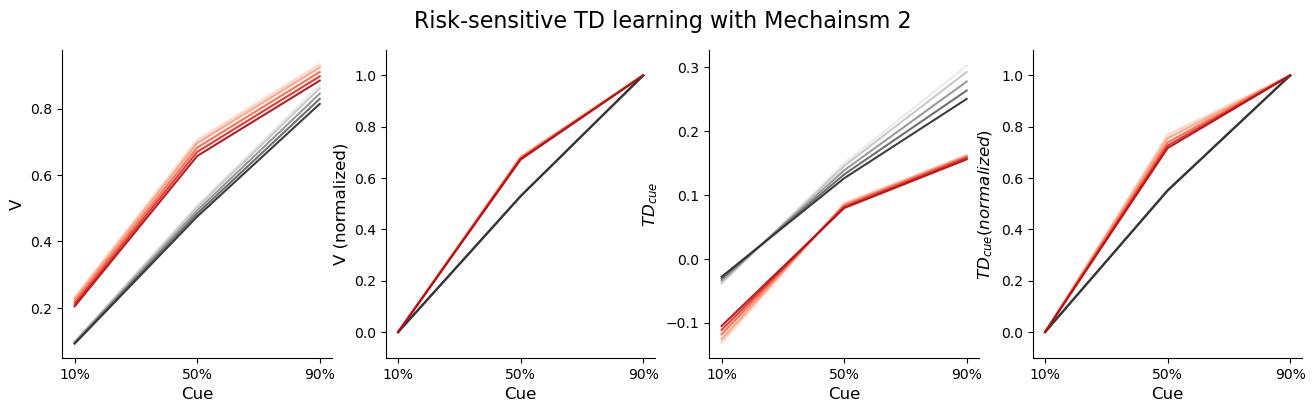

In [9]:
simulation_type = 'eta_nosampling_nodistr_' 

file_type = 'results_sim_type_' + simulation_type + 'eps_'
cs_names = ['10%','50%','90%']
i_group = 0
ntr_count=-200
ieps=0
taus_=np.sort(taus_lin[i_group])
eta_ = .5
id_cue_trtype=[0,1,2]
taus_ = taus_[(taus_>0)*(taus_<1)]
epsilon_ = beta_v[ieps]
agent = create_instance_agent_pav_task(taus_lin[1],eta_,epsilon_)
colors_g = ['black','red']
mu_ieps=dict()
mu_ieps['cue_response_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['baseline_vi_mean']=   np.nan*np.ones((len(beta_v),2))
mu_ieps['baseline_vi_mean_std']=   np.nan*np.ones((len(beta_v),2))

fig,ax = plt.subplots(1,4,figsize=(16,4))
fig_data_simulation = FigureWithData(fig)

for i_eps in range(len(beta_v)):
    eps = beta_v[i_eps]
    
    eps_str = str(eps).replace('.','_')
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_control_*'))
    results_control = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_lesion_*'))
    results_lesion = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    results_l = [rr for rr in results_lesion if len(rr)>0 ]
    results_c = [rr for rr in results_control if len(rr)>0 ]
    #% % Plot means 
    results_v=[results_c,results_l]
    evtype = 'mean'
    vars_n = ['deltas_trials_full','distribution_trials_full']
    save_titles = ['cue_response_mean','vi_mean']
    y_labels = [r'Cue $\delta$',r'$V_i$']
    id_states = [1,3]
    
    id_cs_plot = np.arange(3)
    id_iter_plot = np.arange(0,len(results_c))
    plot_titles = [r'Cue responses (Data)',r'$V_i$ (Data)']

    for (ig,ires) in enumerate(results_v):
        group_name = 'Control' if ig == 0 else 'Lesion'
        td_trial_mu_v,td_trial_n_mu_v = np.nan*np.ones((len(ires),3)),np.nan*np.ones((len(ires),3))
        v_trial_mu_v,v_trial_n_mu_v = np.nan*np.ones((len(ires),3)),np.nan*np.ones((len(ires),3))
        for iiter in range(len(ires)):
            res = ires[iiter]['results']
            td_trial_r = res['deltas_trials_full'][0,[0,2,4],1,:]#
            td_trial_o = res['deltas_trials_full'][0,[1,3,5],1,:]#
            td_trial = np.concatenate((td_trial_r,td_trial_o),axis=1)
            td_trial_mu = np.nanmean(td_trial,axis=-1)
            td_trial_mu_v[iiter,:] = td_trial_mu
            td_trial_n = (td_trial-td_trial_mu[0])/(td_trial_mu[-1]-td_trial_mu[0])
            td_trial_n_mu = np.nanmean(td_trial_n,axis=-1)
            td_trial_n_mu_v[iiter,:] = td_trial_n_mu

            v_trial_r = res['distribution_trials_full'][0,[0,2,4],3,:]#
            v_trial_o = res['distribution_trials_full'][0,[1,3,5],3,:]#
            v_trial = np.concatenate((v_trial_r,v_trial_o),axis=1)
            v_trial_mu = np.nanmean(v_trial,axis=-1)
            v_trial_mu_v[iiter,:] = v_trial_mu
            v_trial_n = (v_trial-v_trial_mu[0])/(v_trial_mu[-1]-v_trial_mu[0])
            v_trial_n_mu = np.nanmean(v_trial_n,axis=-1)
            v_trial_n_mu_v[iiter,:] = v_trial_n_mu

        if ig ==0:
            cg=cm.Greys(i_eps/len(beta_v))
        else:
            cg=cm.Reds(i_eps/len(beta_v))
        ax[0].plot(np.arange(3),np.nanmean(v_trial_mu_v,axis=0),color=cg,alpha=.95)
        ax[1].plot(np.arange(3),np.nanmean(v_trial_n_mu_v,axis=0),color=cg,alpha=.95)
        ax[2].plot(np.arange(3),np.nanmean(td_trial_mu_v,axis=0),color=cg,alpha=.95)
        ax[3].plot(np.arange(3),np.nanmean(td_trial_n_mu_v,axis=0),color=cg,alpha=.95)

        # --- Save means across simulations
        fig_data_simulation.add_data(
            f"V_mean_eps_{eps_str}_{group_name}",
            np.column_stack((np.arange(3), np.nanmean(v_trial_mu_v, axis=0))),
            ['Cue_Index', 'V_mean']
        )
        fig_data_simulation.add_data(
            f"V_norm_mean_eps_{eps_str}_{group_name}",
            np.column_stack((np.arange(3), np.nanmean(v_trial_n_mu_v, axis=0))),
            ['Cue_Index', 'V_norm_mean']
        )
        fig_data_simulation.add_data(
            f"TD_mean_eps_{eps_str}_{group_name}",
            np.column_stack((np.arange(3), np.nanmean(td_trial_mu_v, axis=0))),
            ['Cue_Index', 'TD_mean']
        )
        fig_data_simulation.add_data(
            f"TD_norm_mean_eps_{eps_str}_{group_name}",
            np.column_stack((np.arange(3), np.nanmean(td_trial_n_mu_v, axis=0))),
            ['Cue_Index', 'TD_norm_mean']
        )


plot_config(ax[0],'Cue',r'V',12,False)
plot_config(ax[1],'Cue',r'V (normalized)' ,12,False)
plot_config(ax[2],'Cue',r'$TD_{cue}$',12,False)
plot_config(ax[3],'Cue',r'$TD_{cue} (normalized)$ ' ,12,False)
[ia.set_xticks(np.arange(len(v_trial))) for ia in ax]
[ia.set_xticklabels(['10%','50%','90%']) for ia in ax]
[ia.set_ylim([-.1,1.1]) for ia in [ax[1],ax[3]]]
plt.suptitle('Risk-sensitive TD learning with Mechainsm 2',fontsize=16)

# --- Save all
fig_data_simulation.save(
    base_filename='figure_S6a',
    folder_data= data_fig_dir,
    folder_figures= fig_dir,
)

In [82]:
simulations_dir = os.path.join('data','local','analysis','rl_simulations')

simulation_type = 'eta_sampling_' 
beta_v = [0.001,0.002,0.005,0.01,0.015,0.02] 
for ieps in np.arange(len(beta_v)):
    epsilon_ = beta_v[ieps]
    for i_group in  np.arange(2):
        results_v = list()
        etas = taus_lin[i_group,:]        
        n_iterations = 25 
        taus_= np.sort(taus_g[i_group])
        taus_ = taus_[(taus_>0)*(taus_<1)]
        #% %
        for ie in np.arange(n_iterations):
            if not  np.isnan(etas[ie] ):
                s = dict()
                s['agent'] = dict()
                s['task'] = dict()
                if simulation_type == 'eta_nosampling_' :
                    s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
                    s['agent']['do_sampling'] = False
                elif simulation_type == 'eta_nosampling_nodistr_': 
                    s['agent']['taus'] =   np.asarray([np.nanmean(taus_) ]) # needs to be array 
                    s['agent']['do_sampling'] = False
                elif simulation_type == 'eta_sampling_': 
                    s['agent']['taus'] =  np.sort(taus_) # needs to be array  np.asarray([np.nanmean(taus_) ]) #  np.sort(taus_)
                    s['agent']['do_sampling'] = True

                s['agent']['eta'] = etas[ie]
                print('Processing for eta = '+ str(etas[ie]) + 'epsilon = '+str(epsilon_) + '|| ' +str(ie) + ' of '+str(n_iterations))
                s['agent']['str_agent'] = ['Eta_' + str(etas[ie])]#,'neutral','optimistic']
                s['agent']['epsilon'] = epsilon_
                s['agent']['base_alpha'] = 1 
                s['agent']['gamma'] = 0.99
                
                s['agent']['d1_d2'] = True
                s['task']['prob'] = [[.1, .9],[.5, .5],[.9, .1] ,[.8, .2]]
                s['task']['mags'] = [[1, 0],[1, 0],[1, 0] ,[-1, 0]]
                s['task']['percent_per_cs'] = 1/len(s['task']['mags'])*np.ones((len(s['task']['mags']),1))
                s['task']['cs_id'] = [[0,0],[1,1],[2,2],[3,3]]
                s['task']['str_cs'] = [ '10%','50%','90%','80%Puff']
                s['task']['str_task'] = 'drl_6odor'
                s['task']['n_trials'] = 2000
                s['task']['cue_onset'] = 1
                s['task']['cue_dur'] = 1
                s['task']['rew_onset'] = 3
                s['task']['iti_dur'] = 1
                s['task']['n_iterations'] = 1
                s['task']['type'] = 'cue_reward'

                agent = TDLearning(s)
                agent.initialize_results()
                agent.run_task()
                agent.reformat_results()
                save_dic = dict()
                results = dict()
                save_vars = ['distribution_trials_full', 'distribution_g_trials_full', 'distribution_ng_trials_full',  'deltas_trials_full', 
                             'distribution_ng_trials', 'distribution_g_trials', 'distribution_trials','deltas_trials']
                for ivar in save_vars:
                    temp = agent.results[ivar]
                    if len(temp.shape)==4:
                        id_end = np.argwhere(np.nansum(temp,axis=(0,1,2))==0).flatten()[0]
                        temp = temp[:,:,:,:id_end]
                    results[ivar] = temp
                save_vars = ['distribution','distribution_g','distribution_ng','samp_distribution','deltas','deltas_trials_raw','distribution_std']
                new_dict = vars(agent)
                for ivar in save_vars:
                    results[ivar] = new_dict[ivar]
                agent_dict = dict()
                save_vars=['taus', 'eta', 'str_agent', 'epsilon', 'base_alpha', 'do_sampling', 'gamma',
                            'n_cells', 'task_type', 'n_deliv_rew', 'deliv_rew', 'deliv_cs', 'trial_length', 
                            'n_trials', 'cs_vector', 'us_vector', 'id_states_per_cs', 'n_types', 'n_tr_max', 
                            'i_step_per_cs']
                for ivar in save_vars:
                    agent_dict[ivar] = new_dict[ivar]
                save_dic['results'] = results
                save_dic['agent'] = agent_dict
                save_dic['task'] = vars(agent.task)
                save_dic['eta'] = etas
                np.save(os.path.join(simulations_dir,'results_sim_type_'+ simulation_type 
                + 'eps_' + str(epsilon_).replace('.','_')+'_'+g_names[i_group]+'_iteration_'+str(ie) ),save_dic)
                print('Saving ' + simulations_dir,'results_sim_type_'+simulation_type 
                + 'eps_' + str(epsilon_).replace('.','_')+'_'+g_names[i_group]+'_iteration_'+str(ie) )

Processing for eta = 0.5485640794749749epsilon = 0.001|| 0 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_sampling_eps_0_001_control_iteration_0
Processing for eta = 0.49892232744640674epsilon = 0.001|| 1 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_sampling_eps_0_001_control_iteration_1
Processing for eta = 0.6476778171616318epsilon = 0.001|| 2 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_sampling_eps_0_001_control_iteration_2
Processing for eta = 0.5527251415337265epsilon = 0.001|| 3 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_sampling_eps_0_001_control_iteration_3
Processing for eta = 0.3651013251178255epsilon = 0.001|| 4 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_sampling_eps_0_001_control_iteration_4
Processing for eta = 0.5084845236614342epsilon = 0.001|| 6 of 25
Saving data/local/analysis/rl_simulations results_sim_type_eta_sampling_eps_0_001_control_iteration

Saved figure to figures/figure_S6/figure_6hi.pdf
Saved data and stats to data/figure_data/figure_S6/figure_6hi.txt


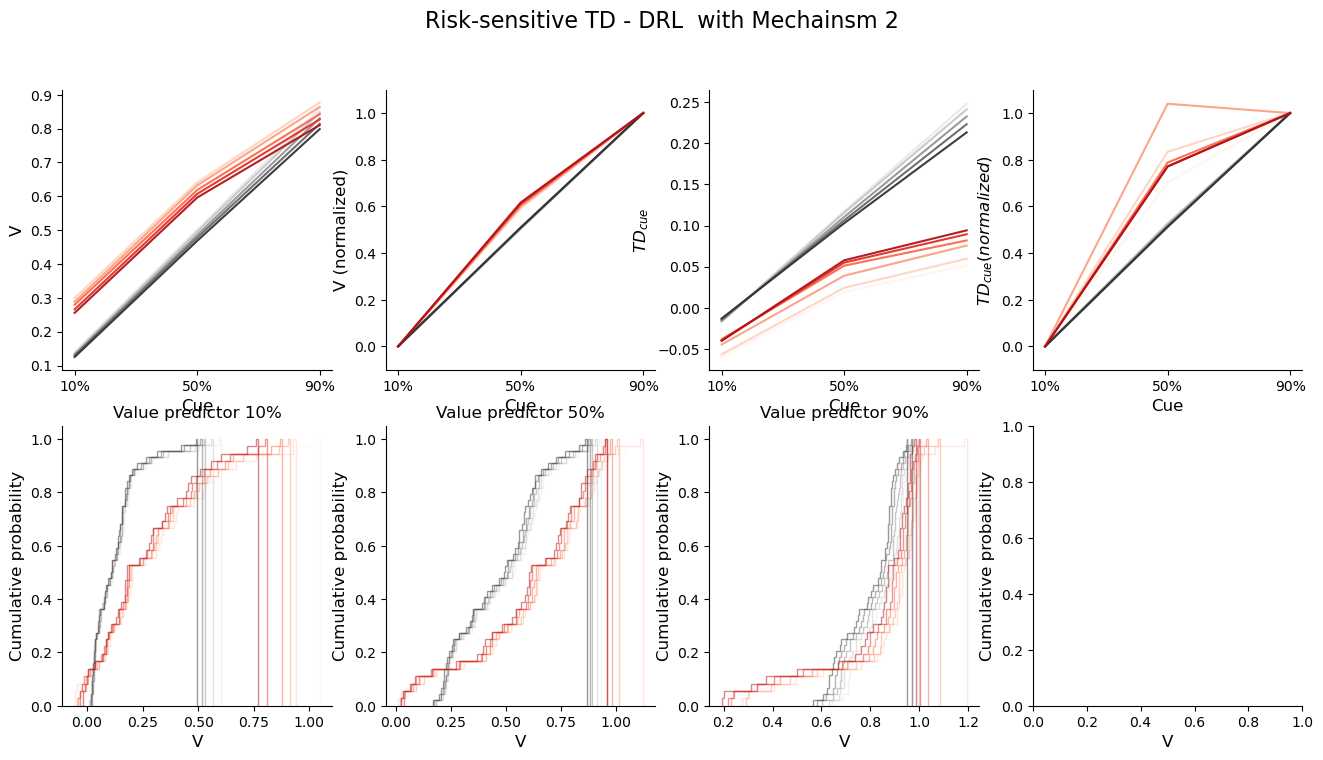

In [ ]:
simulation_type = 'eta_sampling_' 

file_type = 'results_sim_type_' + simulation_type + 'eps_'
cs_names = ['10%','50%','90%']
i_group = 0
ntr_count=-200
ieps=0
taus_=np.sort(taus_lin[i_group])
eta_ = .5
id_cue_trtype=[0,1,2]
taus_ = taus_[(taus_>0)*(taus_<1)]
epsilon_ = beta_v[ieps]
agent = create_instance_agent_pav_task(taus_lin[1],eta_,epsilon_)
colors_g = ['black','red']
mu_ieps=dict()
mu_ieps['cue_response_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['cue_response_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['vi_mean_n_std']=  np.nan*np.ones((len(beta_v),2,4))
mu_ieps['baseline_vi_mean']=   np.nan*np.ones((len(beta_v),2))
mu_ieps['baseline_vi_mean_std']=   np.nan*np.ones((len(beta_v),2))

fig,ax = plt.subplots(2,4,figsize=(16,8))
fig_data_simulation_sampling = FigureWithData(fig)

for i_eps in range(len(beta_v)):
    eps = beta_v[i_eps]
    eps_str = str(eps).replace('.','_')
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_control_*'))
    results_control = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    file_list = glob.glob(os.path.join(simulations_dir ,file_type + eps_str +'_lesion_*'))
    results_lesion = [np.load(ifile, allow_pickle=True).flatten()[0] for ifile in file_list]
    results_l = [rr for rr in results_lesion if len(rr)>0 ]
    results_c = [rr for rr in results_control if len(rr)>0 ]
    #% % Plot means 
    results_v=[results_c,results_l]
    evtype = 'mean'
    vars_n = ['deltas_trials_full','distribution_trials_full']
    save_titles = ['cue_response_mean','vi_mean']
    y_labels = [r'Cue $\delta$',r'$V_i$']
    id_states = [1,3]
    
    id_cs_plot = np.arange(3)
    id_iter_plot = np.arange(0,len(results_c))
    plot_titles = [r'Cue responses (Data)',r'$V_i$ (Data)']
    for (ig,ires) in enumerate(results_v):
        td_trial_mu_v,td_trial_n_mu_v = np.nan*np.ones((len(ires),3)),np.nan*np.ones((len(ires),3))
        v_trial_mu_v,v_trial_n_mu_v = np.nan*np.ones((len(ires),3)),np.nan*np.ones((len(ires),3))
        taus_= np.sort(taus_g[ig])
        v_trial_dist_v= np.nan*np.ones((len(taus_),len(ires),3))
        for iiter in range(len(ires)):
            res = ires[iiter]['results']
            td_trial_r = res['deltas_trials_full'][:,[0,2,4],1,:]#
            td_trial_o = res['deltas_trials_full'][:,[1,3,5],1,:]#
            td_trial = np.concatenate((td_trial_r,td_trial_o),axis=2)
            td_trial_mean_pop = np.nanmean(td_trial,axis=0)
            td_trial_mu = np.nanmean(td_trial_mean_pop,axis=-1)
            td_trial_mu_v[iiter,:] = td_trial_mu
            td_trial_n = (td_trial_mean_pop-td_trial_mu[0])/(td_trial_mu[-1]-td_trial_mu[0])
            td_trial_n_mu = np.nanmean(td_trial_n,axis=-1)
            td_trial_n_mu_v[iiter,:] = td_trial_n_mu

            v_trial_r = res['distribution_trials_full'][:,[0,2,4],3,:]#
            v_trial_o = res['distribution_trials_full'][:,[1,3,5],3,:]#
            v_trial = np.concatenate((v_trial_r,v_trial_o),axis=2)
            v_trial_mean_pop = np.nanmean(v_trial,axis=0)
            v_trial_dist_v[:,iiter,:] =np.nanmean(v_trial,axis=-1)
            v_trial_mu = np.nanmean(v_trial_mean_pop,axis=-1)
            v_trial_mu_v[iiter,:] = v_trial_mu
            v_trial_n = (v_trial_mean_pop-v_trial_mu[0])/(v_trial_mu[-1]-v_trial_mu[0])
            v_trial_n_mu = np.nanmean(v_trial_n,axis=-1)
            v_trial_n_mu_v[iiter,:] = v_trial_n_mu


        if ig ==0:
            cg=cm.Greys(i_eps/len(beta_v))
        else:
            cg=cm.Reds(i_eps/len(beta_v))

        ax[0,0].plot(np.arange(3),np.nanmean(v_trial_mu_v,axis=0),color=cg,alpha=.95)
        ax[0,1].plot(np.arange(3),np.nanmean(v_trial_n_mu_v,axis=0),color=cg,alpha=.95)
        ax[0,2].plot(np.arange(3),np.nanmean(td_trial_mu_v,axis=0),color=cg,alpha=.95)
        ax[0,3].plot(np.arange(3),np.nanmean(td_trial_n_mu_v,axis=0),color=cg,alpha=.95)
        
        # Plot empirical CDF for value predictors for each trial type
        v_trial_dist_v_mu= np.nanmean(v_trial_dist_v,axis=1)
        ax[1,0].hist(v_trial_dist_v_mu[:,0],bins=100,alpha=.5,color=cg, cumulative=True, density=True,histtype='step')  
        ax[1,1].hist(v_trial_dist_v_mu[:,1],bins=100,alpha=.5,color=cg, cumulative=True, density=True,histtype='step')  
        ax[1,2].hist(v_trial_dist_v_mu[:,2],bins=100,alpha=.5,color=cg, cumulative=True, density=True,histtype='step')  

        # --- Save mean curves
        fig_data_simulation_sampling.add_data(
            f"V_mean_eps_{eps_str}_{group_name}",
            np.column_stack((np.arange(3), np.nanmean(v_trial_mu_v, axis=0))),
            ['Cue_Index', 'V_mean']
        )
        fig_data_simulation_sampling.add_data(
            f"V_norm_mean_eps_{eps_str}_{group_name}",
            np.column_stack((np.arange(3), np.nanmean(v_trial_n_mu_v, axis=0))),
            ['Cue_Index', 'V_norm_mean']
        )
        fig_data_simulation_sampling.add_data(
            f"TD_mean_eps_{eps_str}_{group_name}",
            np.column_stack((np.arange(3), np.nanmean(td_trial_mu_v, axis=0))),
            ['Cue_Index', 'TD_mean']
        )
        fig_data_simulation_sampling.add_data(
            f"TD_norm_mean_eps_{eps_str}_{group_name}",
            np.column_stack((np.arange(3), np.nanmean(td_trial_n_mu_v, axis=0))),
            ['Cue_Index', 'TD_norm_mean']
        )

        # --- Save empirical CDF histograms for each cue
        for icue in range(3):
            fig_data_simulation_sampling.add_data(
                f"CDF_value_eps_{eps_str}_{group_name}_cue_{icue}",
                v_trial_dist_v[:, :, icue],
                [f'Simulation_{i}' for i in range(v_trial_dist_v.shape[0])]
            )
        # plt.hist()
plot_config(ax[0,0],'Cue',r'V',12,False)
plot_config(ax[0,1],'Cue',r'V (normalized)' ,12,False)
plot_config(ax[0,2],'Cue',r'$TD_{cue}$',12,False)
plot_config(ax[0,3],'Cue',r'$TD_{cue} (normalized)$ ' ,12,False)

[plot_config(ia,'V','Cumulative probability' ,12,False) for ia in ax[1,:]]
[ia.set_title('Value predictor '+ str_cs) for (ia,str_cs) in zip(ax[1,:],cs_names)]
[ia.set_xticks(np.arange(len(cs_names))) for ia in ax[0,:]]
[ia.set_xticklabels(cs_names) for ia in ax[0,:]]
[ia.set_ylim([-.1,1.1]) for ia in [ax[0,1],ax[0,3]]]
plt.suptitle('Risk-sensitive TD - DRL  with Mechainsm 2',fontsize=16)


# --- Save everything
fig_data_simulation_sampling.save(
    base_filename='figure_6hi',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)